# Diagnostics! 

#### Importing functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import sys, os
sys.path.append(os.path.abspath("../../"))    # Calling the HorizonFinder.py source code from src
from src.source_v3_2 import nosym

#### Data produced

In [2]:
# Load data from HDF5 file
with h5py.File("./data/horizon_common.h5", 'r') as f:
    theta = f['theta'][:]
    phi = f['phi'][:]
    h = f['h'][:]

M = 1.0

Ntheta = len(theta)
Nphi = len(phi)

#### Plots

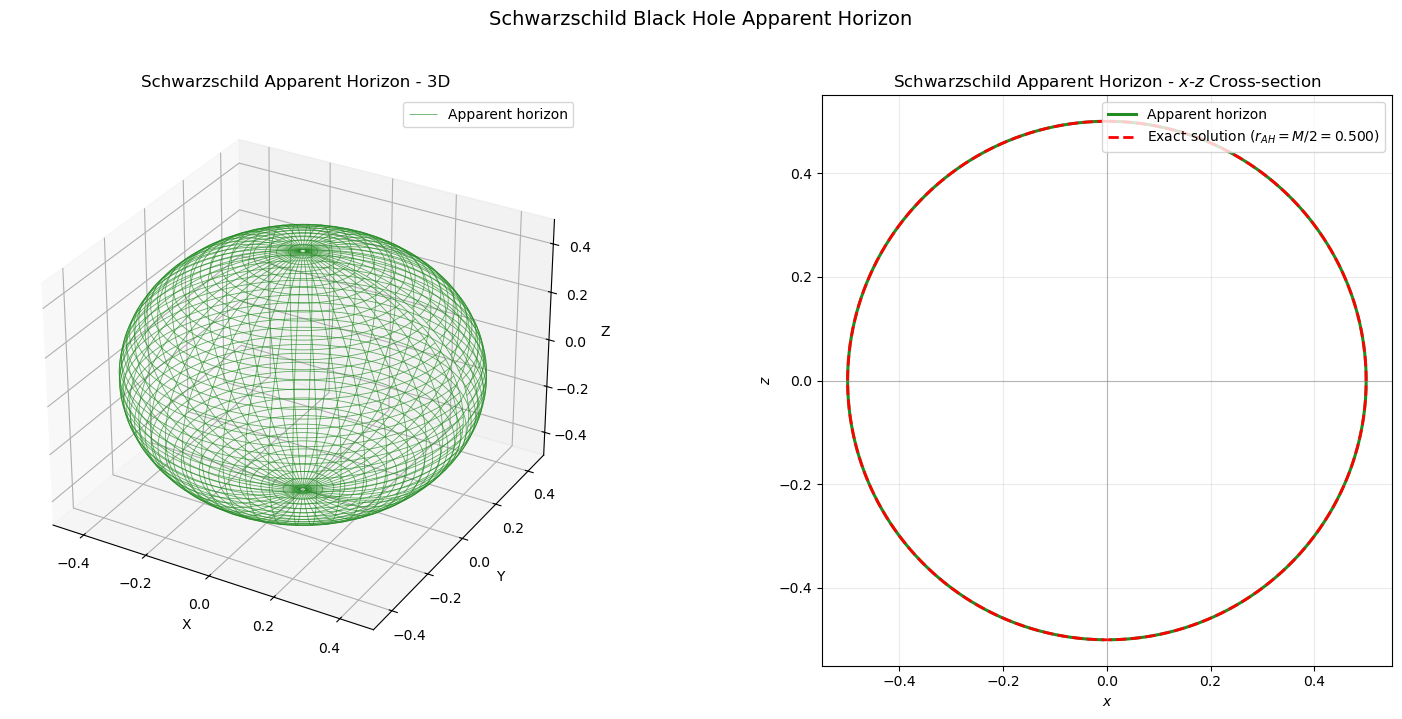

In [12]:
# Combined figure in the same style as the reference: 3D + x-z cross-section
fig = plt.figure(figsize=(16, 7))

# ---------- Left panel: 3D horizon ----------
ax3d = fig.add_subplot(1, 2, 1, projection='3d')

THETA, PHI = np.meshgrid(theta, phi, indexing='ij')
R = h
X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

ax3d.plot_wireframe(X, Y, Z, color='forestgreen', linewidth=0.6, alpha=0.7, label='Apparent horizon')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Schwarzschild Apparent Horizon - 3D')
ax3d.legend(loc='upper right')

max_range = np.max(np.abs(R))
ax3d.set_xlim([-max_range, max_range])
ax3d.set_ylim([-max_range, max_range])
ax3d.set_zlim([-max_range, max_range])

# ---------- Right panel: x-z cross-section ----------
ax2d = fig.add_subplot(1, 2, 2)

# A proper x-z closed section uses both phi=0 (x>0) and phi=pi (x<0)
phi_idx_0 = np.argmin(np.abs(phi - 0.0))
phi_idx_pi = np.argmin(np.abs(phi - np.pi))

h_section_0 = h[:, phi_idx_0]
h_section_pi = h[:, phi_idx_pi]

x_pos = h_section_0 * np.sin(theta)
x_neg = h_section_pi * np.sin(theta) * np.cos(np.pi)  # ensures negative-x branch
z_pos = h_section_0 * np.cos(theta)
z_neg = h_section_pi * np.cos(theta)

# Plot both branches to form the full closed contour
ax2d.plot(x_pos, z_pos, color='forestgreen', linewidth=2.2, label='Apparent horizon')
ax2d.plot(x_neg, z_neg, color='forestgreen', linewidth=2.2)

# Exact Schwarzschild apparent horizon in isotropic coordinates: r_AH = M/2
theta_exact = np.linspace(0, 2 * np.pi, 400)
r_ah_exact = M / 2.0
x_exact = r_ah_exact * np.sin(theta_exact)
z_exact = r_ah_exact * np.cos(theta_exact)
ax2d.plot(x_exact, z_exact, 'r--', linewidth=2.0, label=f'Exact solution ($r_{{AH}}=M/2={r_ah_exact:.3f}$)')

ax2d.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax2d.axvline(0, color='gray', lw=0.8, alpha=0.5)
ax2d.set_xlabel('$x$')
ax2d.set_ylabel('$z$')
ax2d.set_title(r'Schwarzschild Apparent Horizon - $x$-$z$ Cross-section')
ax2d.set_aspect('equal', adjustable='box')
ax2d.grid(True, alpha=0.25)
ax2d.legend(loc='upper right')

fig.suptitle('Schwarzschild Black Hole Apparent Horizon', fontsize=14, y=1.02)
plt.tight_layout()

os.makedirs('./plots', exist_ok=True)
plt.savefig('./plots/horizon.png', dpi=300, bbox_inches='tight')
plt.show()